Part 1: Random X and Y
Custom: m = 0.2469, b = 0.2822
Numpy:  m = 0.2469, b = 0.2822
Slope difference: 0.000000
Intercept difference: 0.000000

Part 2: Generated line
Original: y = 2.5000x + 1.2000
Custom:   y = 2.4503x + 1.3321
Numpy:    y = 2.4503x + 1.3321
Slope difference: 0.000000
Intercept difference: 0.000000

Residuals:
[-1.0225e+00  6.9670e-01  1.3360e-01 -6.5240e-01 -7.7200e-02 -1.0066e+00
  7.5190e-01  4.6270e-01  6.8000e-02 -8.3540e-01 -8.6310e-01  2.8840e-01
 -3.0430e-01  6.3380e-01  9.0000e-04  5.7020e-01 -4.0420e-01  4.7420e-01
  7.4270e-01 -8.1820e-01  2.1790e-01  6.3750e-01  5.8850e-01 -5.8520e-01
  5.1920e-01  9.6300e-02 -7.1400e-02 -1.2300e-02 -7.6620e-01  4.0350e-01
 -1.0465e+00  3.7870e-01  7.2880e-01 -2.7600e-01 -3.5440e-01 -8.0000e-01
  3.4520e-01  2.9450e-01 -9.0500e-02  5.9060e-01  2.8600e-01  1.2970e-01
  3.1870e-01 -6.1600e-01 -5.2300e-01 -7.7700e-02  4.4110e-01  7.0840e-01
 -4.8400e-01 -2.2980e-01  3.4270e-01 -1.8600e-02 -8.0830e-01  3.4690e-01
  6.2820e-01 

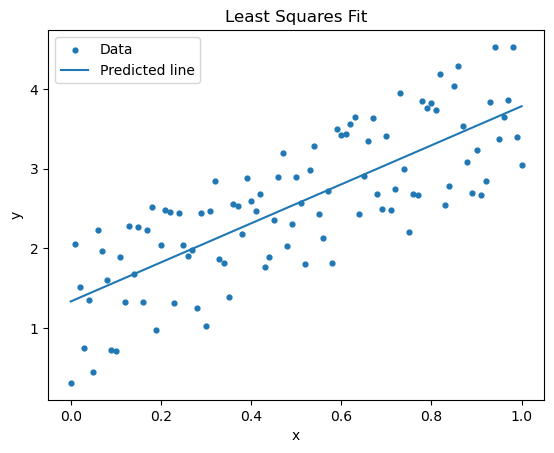

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ChatGPT was used to help check the least-squares formulas
# and to help organize the steps of the assignment

def least_squares(x, y):
    n = len(x)
    m = (n*np.sum(x*y) - np.sum(x)*np.sum(y)) / (n*np.sum(x**2) - np.sum(x)**2)
    b = (np.sum(y) - m*np.sum(x)) / n
    return m, b

rng = np.random.default_rng(311)

# Part 1: random X and Y
x1 = np.sort(rng.random(8))
y1 = rng.random(8)

m1, b1 = least_squares(x1, y1)

A1 = np.vstack([x1, np.ones(len(x1))]).T
m1_np, b1_np = np.linalg.lstsq(A1, y1, rcond=None)[0]

print("Part 1: Random X and Y")
print(f"Custom: m = {m1:.4f}, b = {b1:.4f}")
print(f"Numpy:  m = {m1_np:.4f}, b = {b1_np:.4f}")
print(f"Slope difference: {abs(m1 - m1_np):.6f}")
print(f"Intercept difference: {abs(b1 - b1_np):.6f}")

# Part 2: make your own linear data with random error
m_true = 2.5
b_true = 1.2

x2 = np.arange(0, 1.01, 0.01)
noise = rng.uniform(-1, 1, len(x2))
y2 = m_true*x2 + b_true + noise

m2, b2 = least_squares(x2, y2)

A2 = np.vstack([x2, np.ones(len(x2))]).T
m2_np, b2_np = np.linalg.lstsq(A2, y2, rcond=None)[0]

y_fit = m2*x2 + b2
residuals = y2 - y_fit

i_max = np.argmax(np.abs(residuals))
i_min = np.argmin(np.abs(residuals))

print("\nPart 2: Generated line")
print(f"Original: y = {m_true:.4f}x + {b_true:.4f}")
print(f"Custom:   y = {m2:.4f}x + {b2:.4f}")
print(f"Numpy:    y = {m2_np:.4f}x + {b2_np:.4f}")
print(f"Slope difference: {abs(m2 - m2_np):.6f}")
print(f"Intercept difference: {abs(b2 - b2_np):.6f}")

print("\nResiduals:")
print(np.round(residuals, 4))

print(f"\nLargest absolute residual: {residuals[i_max]:.4f} at x = {x2[i_max]:.2f}, y = {y2[i_max]:.4f}")
print(f"Smallest absolute residual: {residuals[i_min]:.4f} at x = {x2[i_min]:.2f}, y = {y2[i_min]:.4f}")

plt.scatter(x2, y2, s=12, label="Data")
plt.plot(x2, y_fit, label="Predicted line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Least Squares Fit")
plt.legend()
plt.show()